<a href="https://colab.research.google.com/github/ahad77/CardioStat-Exploratory-Data-Analysis-of-Heart-Disease-Risk-Factors/blob/main/heart_disease_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

In [ ]:
%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

print("🛠️ Environment Ready")

🛠️ Environment Ready


***Data Acquisition***

In [ ]:
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "johnsmith88/heart-disease-dataset",
  "heart.csv",
)
print(f"Dataset loaded. Total records: {len(df)}")

Using Colab cache for faster access to the 'heart-disease-dataset' dataset.
Dataset loaded. Total records: 1025


***Data Validation***

In [ ]:
print("--- Data Snapshot ---")
display(df.head())

print("\n--- Schema and Null Analysis ---")
df.info()
print("\nMissing Values:", df.isnull().sum().sum())

--- Data Snapshot ---


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0



--- Schema and Null Analysis ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB

Missing Values: 0


***Categorical Distribution***

In [ ]:
target_dist = df['target'].value_counts(normalize=False)
gender_dist = df['sex'].value_counts(normalize=False)

print("Target Class Balance:\n", target_dist)
print("\nGender Distribution:\n", gender_dist)

Target Class Balance:
 target
1    526
0    499
Name: count, dtype: int64

Gender Distribution:
 sex
1    713
0    312
Name: count, dtype: int64


Visualizing the Target Distribution

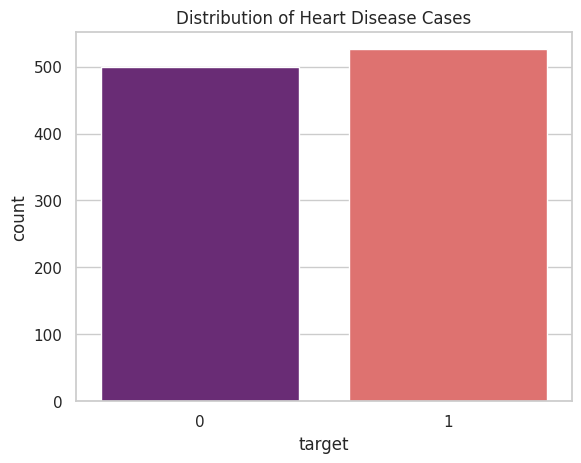

In [ ]:
sns.countplot(data=df, x='target', palette='magma', hue='target', legend=False)
plt.title('Distribution of Heart Disease Cases')
plt.show()

***Feature Selection***

Accessing specific feature sets (Age, Sex, Cholesterol)

In [ ]:
feature_subset = df.iloc[:, [0, 1, 4]]
display(feature_subset.head(10))

,age,sex,chol
0,52,1,212
1,53,1,203
2,70,1,174
3,61,1,203
4,62,0,294
5,58,0,248
6,58,1,318
7,55,1,289
8,46,1,249
9,54,1,286


Index-based range extraction

In [ ]:
range_subset = df.iloc[20:31, 0:5]

***Conditional Logic***

In [ ]:
older_50_mask = df['age'] > 50
high_risk_mask = (df['target'] == 1) & (df['chol'] > 240)

print(f"Patients > 50: {older_50_mask.sum()}")
print(f"High Risk (Disease + Chol > 240): {high_risk_mask.sum()}")

Patients > 50: 710
High Risk (Disease + Chol > 240): 222


View the filtered cohort

In [ ]:
display(df[high_risk_mask].head())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
16,51,0,2,140,308,0,0,142,0,1.5,2,1,2,1
18,50,0,1,120,244,0,1,162,0,1.1,2,0,2,1
23,63,0,2,135,252,0,0,172,0,0.0,2,0,2,1
31,50,0,1,120,244,0,1,162,0,1.1,2,0,2,1
